# BGL Realtime (Accumulator + Streaming PCA Scorer)

This notebook replays the BGL dataset from file and processes it in chunks using:

- Preprocessor + Drain3 Template Parser (as in the demo-system)
- Realtime Accumulator (tumbling windows + hashed features)
- StreamingPCAScorer (incremental warmup, then frozen SPE scoring)

Outputs Parquet parts for windowed/event_matrix/anomalies and prints throughput metrics.

In [ ]:
from pathlib import Path
import time

import numpy as np
import polars as pl

# repo & data
REPO_ROOT = (Path.cwd() / ".." / "..").resolve()
DATASET = REPO_ROOT / "data" / "raw" / "labeled" / "BGL" / "BGL.log"

# outputs
OUT = (REPO_ROOT / "data" / "results" / "bgl_realtime_rtclasses").resolve()
for d in ["windowed", "event_matrix", "anomalies"]:
    (OUT / d).mkdir(parents=True, exist_ok=True)

# streaming params
WINDOW_SIZE = "10m"
ALLOWED_LATENESS = "0s"
CHUNK_SIZE = 25000

# feature hashing
HASH_BINS = 4096
HASH_SIGNED = True
# no per-window normalization (use raw counts)

# PCA / detection
WARMUP_WINDOWS = 4000
VARIANCE_THRESHOLD = 0.95
ALPHA_SPE = 1e-3
USE_SCALING = True

print("Dataset exists:", DATASET.exists())
print("Output:", OUT)

Dataset exists: True
Output: /home/mih/cs/elfak/diplomski/log-anomaly-analysis/log-anomaly-analysis/data/results/bgl_realtime_rtclasses


In [2]:
from log_anomaly_analysis.core.config.loader import load_config
from log_anomaly_analysis.core.components.preprocessing import PreprocessorComponent
from log_anomaly_analysis.core.components.parsing import TemplateParserComponent
from log_anomaly_analysis.realtime import Accumulator, StreamingPCAScorer


def iterate_file(path: Path, chunk_size: int):
    with path.open("r", encoding="utf-8", errors="ignore") as fh:
        chunk = []
        for ln in fh:
            s = ln.strip()
            if s:
                chunk.append(s)
            if len(chunk) >= chunk_size:
                yield chunk
                chunk = []
        if chunk:
            yield chunk


# parquet part counters
part = {"windowed": 0, "event_matrix": 0, "anomalies": 0}


def write_df(dir_path: Path, name: str, df: pl.DataFrame):
    if df is None or df.is_empty():
        return
    p = dir_path / f"part-{part[name]:05d}.parquet"
    df.write_parquet(p)
    part[name] += 1


# load config for preprocessing/parsing
cfg = load_config(REPO_ROOT / "configs" / "labeled" / "BGL.yaml")
pre = PreprocessorComponent(cfg.preprocessing.__dict__)
parser = TemplateParserComponent(cfg.parsing.__dict__)

# initialize accumulator and scorer
acc = Accumulator(
    {
        "window_size": WINDOW_SIZE,
        "allowed_lateness": ALLOWED_LATENESS,
        "hash_bins": HASH_BINS,
        "hash_signed": HASH_SIGNED,
        # no per-window normalization
    }
)

scorer = StreamingPCAScorer(
    {
        "variance_threshold": VARIANCE_THRESHOLD,
        "alpha": ALPHA_SPE,
        "use_scaling": USE_SCALING,
        "warmup_windows": WARMUP_WINDOWS,
        "max_components": 512,
        "min_residual_eigs": 16,
    }
)

total_logs = 0
total_windows = 0
total_anomalies = 0
t0 = time.perf_counter()

print("Components ready.")

Components ready.


In [3]:
for lines in iterate_file(DATASET, CHUNK_SIZE):
    # preprocess => templates
    df = pl.DataFrame({"raw_log": lines})
    pre_df = pre.process(df)
    if pre_df.is_empty():
        continue

    parsed_df = parser.process(pre_df)
    if parsed_df.is_empty():
        continue

    total_logs += len(parsed_df)

    # collect fields
    ts = parsed_df["Timestamp"].to_list()
    tpl = (
        parsed_df["TemplateId"].to_list()
        if "TemplateId" in parsed_df.columns
        else parsed_df["EventTemplate"].to_list()
    )

    # update window accumulator
    acc.update_chunk(ts, tpl)
    win_df, feat_df = acc.finalize_ready()

    if not win_df.is_empty():
        write_df(OUT / "windowed", "windowed", win_df)
        total_windows += len(win_df)

    if not feat_df.is_empty():
        write_df(OUT / "event_matrix", "event_matrix", feat_df)
        # Build X from hashed bins
        cols = [str(i) for i in range(HASH_BINS)]
        X = (
            feat_df.select(cols).to_numpy().astype(np.float32, copy=False)
        )
        # Warmup (incremental) or scoring
        if not scorer.warmed:
            scorer.partial_fit_warmup(X)
        else:
            S, yhat = scorer.score(X)
            anom_df = pl.DataFrame({
                "Window": feat_df["Window"],
                "WindowStart": feat_df["WindowStart"],
                "WindowEnd": feat_df["WindowEnd"],
                "LogCount": feat_df["LogCount"],
                "AnomalyScore_SPE": S,
                "IsAnomaly": yhat,
            })
            write_df(OUT / "anomalies", "anomalies", anom_df)
            total_anomalies += int(yhat.sum())

# flush remainder
win_df, feat_df = acc.finalize_all()
if not win_df.is_empty():
    write_df(OUT / "windowed", "windowed", win_df)
    total_windows += len(win_df)
if not feat_df.is_empty():
    write_df(OUT / "event_matrix", "event_matrix", feat_df)
    cols = [str(i) for i in range(HASH_BINS)]
    X = feat_df.select(cols).to_numpy().astype(np.float32, copy=False)
    if not scorer.warmed:
        scorer.partial_fit_warmup(X)
    else:
        S, yhat = scorer.score(X)
        anom_df = pl.DataFrame({
            "Window": feat_df["Window"],
            "WindowStart": feat_df["WindowStart"],
            "WindowEnd": feat_df["WindowEnd"],
            "LogCount": feat_df["LogCount"],
            "AnomalyScore_SPE": S,
            "IsAnomaly": yhat,
        })
        write_df(OUT / "anomalies", "anomalies", anom_df)
        total_anomalies += int(yhat.sum())

t1 = time.perf_counter()
dur = t1 - t0
logs_per_s = total_logs / dur if dur > 0 else 0.0
wins_per_s = total_windows / dur if dur > 0 else 0.0
print(f"Processed {total_logs:,} logs -> {total_windows:,} windows, {total_anomalies:,} anomalies in {dur:.1f}s | {logs_per_s:.1f} logs/s, {wins_per_s:.1f} wins/s")

2025-10-06 01:44:00.681 | INFO     | log_anomaly_analysis.core.components.parsing:process:110 - Extracted 20 unique templates from 25000 logs
2025-10-06 01:44:01.909 | INFO     | log_anomaly_analysis.core.components.parsing:process:110 - Extracted 46 unique templates from 25000 logs
2025-10-06 01:44:03.159 | INFO     | log_anomaly_analysis.core.components.parsing:process:110 - Extracted 34 unique templates from 25000 logs
2025-10-06 01:44:04.309 | INFO     | log_anomaly_analysis.core.components.parsing:process:110 - Extracted 12 unique templates from 25000 logs
2025-10-06 01:44:05.427 | INFO     | log_anomaly_analysis.core.components.parsing:process:110 - Extracted 14 unique templates from 25000 logs
2025-10-06 01:44:06.712 | INFO     | log_anomaly_analysis.core.components.parsing:process:110 - Extracted 15 unique templates from 25000 logs
2025-10-06 01:44:07.865 | INFO     | log_anomaly_analysis.core.components.parsing:process:110 - Extracted 52 unique templates from 25000 logs
2025-1

Processed 4,747,963 logs -> 10,555 windows, 1,613 anomalies in 289.9s | 16380.2 logs/s, 36.4 wins/s


Windows: 10555 | TP=389 FP=1224 FN=544 TN=8398
Precision=0.2412 Recall=0.4169 F1=0.3056


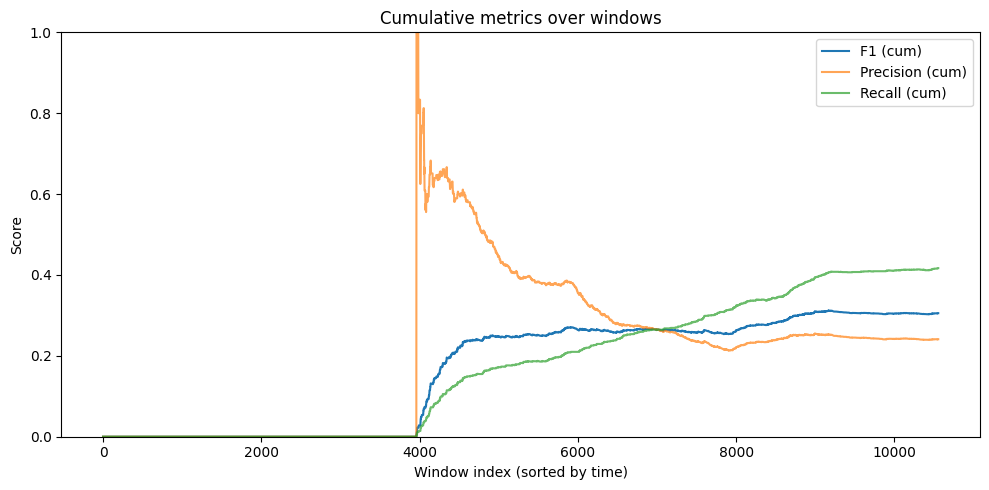

In [4]:
# Evaluate against BGL labels (window-level)
import matplotlib.pyplot as plt

# Load predictions
anom_files = sorted((OUT / "anomalies").glob("*.parquet"))
if anom_files:
    pred_df = pl.concat(
        [pl.read_parquet(f) for f in anom_files], how="vertical", rechunk=True
    )
    pred_df = (
        pred_df.unique(subset=["Window"], keep="last")
        .select(["Window", "IsAnomaly"])
        .sort("Window")
    )
else:
    pred_df = pl.DataFrame({"Window": [], "IsAnomaly": []})

# Build ground-truth window labels by re-parsing BGL labels
gt_map: dict = {}
for lines in iterate_file(DATASET, CHUNK_SIZE):
    df = pl.DataFrame({"raw_log": lines})
    pre_df = pre.process(df)
    if pre_df.is_empty() or ("Label" not in pre_df.columns):
        continue
    w = (
        pre_df.select(
            [
                pl.col("Timestamp").dt.truncate(WINDOW_SIZE).alias("Window"),
                pl.col("Label"),
            ]
        )
        .with_columns(
            pl.when(pl.col("Label") != "-").then(True).otherwise(False).alias("IsAnom")
        )
        .group_by("Window", maintain_order=True)
        .agg(pl.col("IsAnom").any().alias("GT"))
    )
    for row in w.iter_rows(named=True):
        k = row["Window"]
        y = bool(row["GT"])
        gt_map[k] = gt_map.get(k, False) or y

gt_df = pl.from_dicts([{"Window": k, "GT": v} for k, v in gt_map.items()]).sort(
    "Window"
)

# Join predictions with ground truth
joined = pred_df.join(gt_df, on="Window", how="full").fill_null(False)
y_pred = joined["IsAnomaly"].to_numpy().astype(bool)
y_true = joined["GT"].to_numpy().astype(bool)

TP = int(((y_pred == 1) & (y_true == 1)).sum())
FP = int(((y_pred == 1) & (y_true == 0)).sum())
FN = int(((y_pred == 0) & (y_true == 1)).sum())
TN = int(((y_pred == 0) & (y_true == 0)).sum())

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1 = (
    (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
)

print(f"Windows: {len(joined)} | TP={TP} FP={FP} FN={FN} TN={TN}")
print(f"Precision={precision:.4f} Recall={recall:.4f} F1={f1:.4f}")

# Cumulative curves over windows (sorted by time)
cum_TP = np.cumsum(((y_pred == 1) & (y_true == 1)).astype(int))
cum_FP = np.cumsum(((y_pred == 1) & (y_true == 0)).astype(int))
cum_FN = np.cumsum(((y_pred == 0) & (y_true == 1)).astype(int))
eps = 1e-9
prec_curve = cum_TP / np.maximum(cum_TP + cum_FP, 1)
rec_curve = cum_TP / np.maximum(cum_TP + cum_FN, 1)
f1_curve = (2 * prec_curve * rec_curve) / np.maximum(prec_curve + rec_curve, eps)

plt.figure(figsize=(10, 5))
plt.plot(f1_curve, label="F1 (cum)")
plt.plot(prec_curve, label="Precision (cum)", alpha=0.7)
plt.plot(rec_curve, label="Recall (cum)", alpha=0.7)
plt.xlabel("Window index (sorted by time)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.title("Cumulative metrics over windows")
plt.tight_layout()
plt.show()